## Minimal example of calculating NPQ-corrected fluorescence from float data

This notebook defines the function for calculating NPQ-corrected fluorescence from uncalibrated float `CHLA_FLUORESCENCE`, and applies it to some data from float ID 5906765 in the equatorial Pacific.

### Import packages, define function, read in float data

In [3]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt

In [1]:
from scripts.npqc import calculate_NPQ_fluo

In [5]:
ds_fl = xr.open_dataset('data/2903884_Sprof.nc')

### Calculate and plot for the first 10 profiles

In [6]:
ds = ds_fl.isel(N_PROF=slice(10))   
(fl_npq, fl_smooth) = calculate_NPQ_fluo(ds)

(250.0, 0.0)

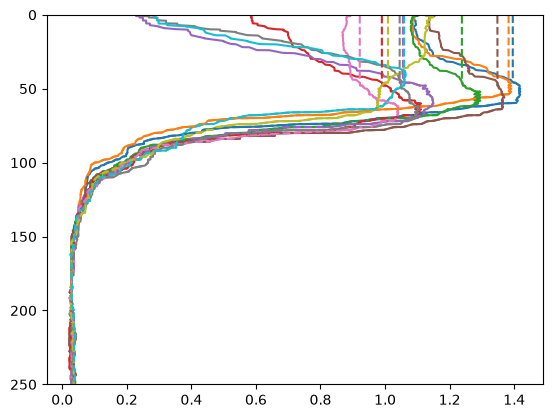

In [7]:
fig, ax = plt.subplots()
plt.plot(fl_smooth.T, ds['PRES_ADJUSTED'].T, '-')
plt.plot(fl_npq.T, ds['PRES_ADJUSTED'].T, '--')
# match line colors
h1 = ax.get_children()
for hh in range(11, 20):
    h1[hh].set_color(h1[hh-10].get_color())
ax.set_ylim([250, 0])